In [1]:
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import torch
import requests

c:\Users\Taha\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Using a Pre-trained ViT for Image Classification

In [2]:
model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)
vit_model = ViTForImageClassification.from_pretrained(model_name, attn_implementation="eager")
vit_model.eval()

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 2410.74it/s]


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear

In [3]:
url1 = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQdDY2Lx59tqT_UEnozT8GN8POQUzoysJmtdH1yUznR-Q&s=10"
url2 = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRPg-YwMm_bHJvR4oKd_PCARiKHZQ1aaUQ87ncOJQtYWkBmZUTTBtLbzBd6&s=10"
url3 = "https://encrypted-tbn2.gstatic.com/images?q=tbn:ANd9GcR0xnD7XburIv-UW8Z2BgkzUtYewUKbuMjCls6wrolVQq4pv0tC"

image1 = Image.open(requests.get(url1, stream=True).raw).convert("RGB")
image2 = Image.open(requests.get(url2, stream=True).raw).convert("RGB")
image3 = Image.open(requests.get(url3, stream=True).raw).convert("RGB")

images = [image1, image2, image3]

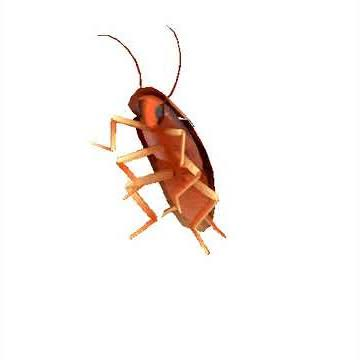

In [4]:
image1

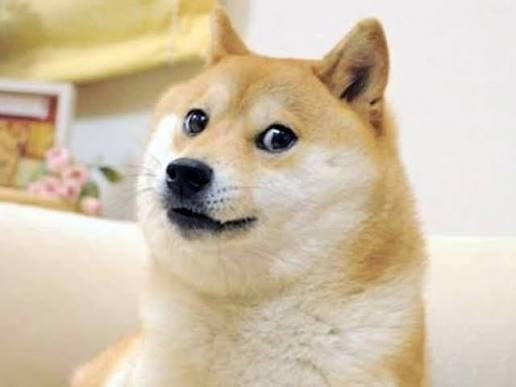

In [5]:
image2

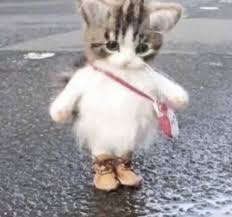

In [6]:
image3

In [7]:
for image in images:
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = vit_model(**inputs)

    pred_idx = outputs.logits.argmax(-1).item()
    pred_label = vit_model.config.id2label[pred_idx]
    print(f"predicted = {pred_label}")

predicted = cockroach, roach
predicted = Eskimo dog, husky
predicted = tabby, tabby cat


## 2. Visualizing Patch Attention

In [8]:
with torch.no_grad():
    outputs = vit_model(**inputs, output_attentions=True)

In [9]:
attentions = outputs.attentions

final_layer_attn = attentions[-1]
print(final_layer_attn.shape)

torch.Size([1, 12, 197, 197])


In [10]:
avg_attn = final_layer_attn[0].mean(dim=0)
avg_attn, avg_attn.shape

(tensor([[0.0005, 0.0010, 0.0007,  ..., 0.0005, 0.0007, 0.0011],
         [0.0019, 0.0006, 0.0004,  ..., 0.0007, 0.0009, 0.0010],
         [0.0019, 0.0006, 0.0003,  ..., 0.0007, 0.0009, 0.0010],
         ...,
         [0.0026, 0.0036, 0.0030,  ..., 0.0006, 0.0004, 0.0011],
         [0.0028, 0.0032, 0.0024,  ..., 0.0007, 0.0002, 0.0006],
         [0.0031, 0.0028, 0.0019,  ..., 0.0011, 0.0006, 0.0010]]),
 torch.Size([197, 197]))

In [11]:
cls_attn = avg_attn[0, 1:]
cls_attn.shape

torch.Size([196])

In [12]:
num_patches_per_side = 14
attn_map = cls_attn.reshape(num_patches_per_side, num_patches_per_side)

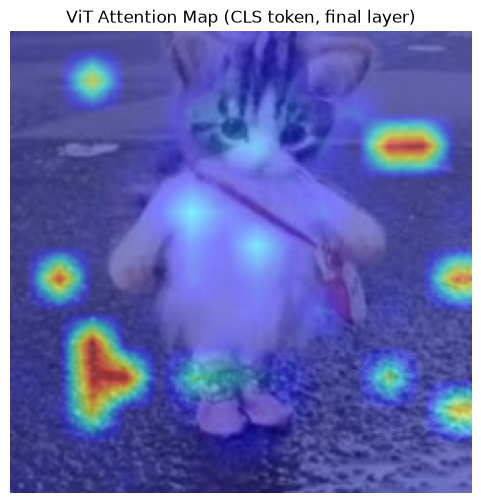

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

attn_map_np = attn_map.numpy()
attn_map_np = (attn_map_np - attn_map_np.min()) / (attn_map_np.max() - attn_map_np.min())

attn_img = Image.fromarray((attn_map_np * 255).astype(np.uint8))
attn_img_resized = attn_img.resize((224, 224), resample=Image.BILINEAR)
attn_resized_np = np.array(attn_img_resized) / 255.0

original_resized = image.resize((224, 224))


plt.figure(figsize=(6, 6))
plt.imshow(original_resized)
plt.imshow(attn_resized_np, cmap="jet", alpha=0.5)
plt.axis("off")
plt.title("ViT Attention Map (CLS token, final layer)")
plt.savefig("vit_attention_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

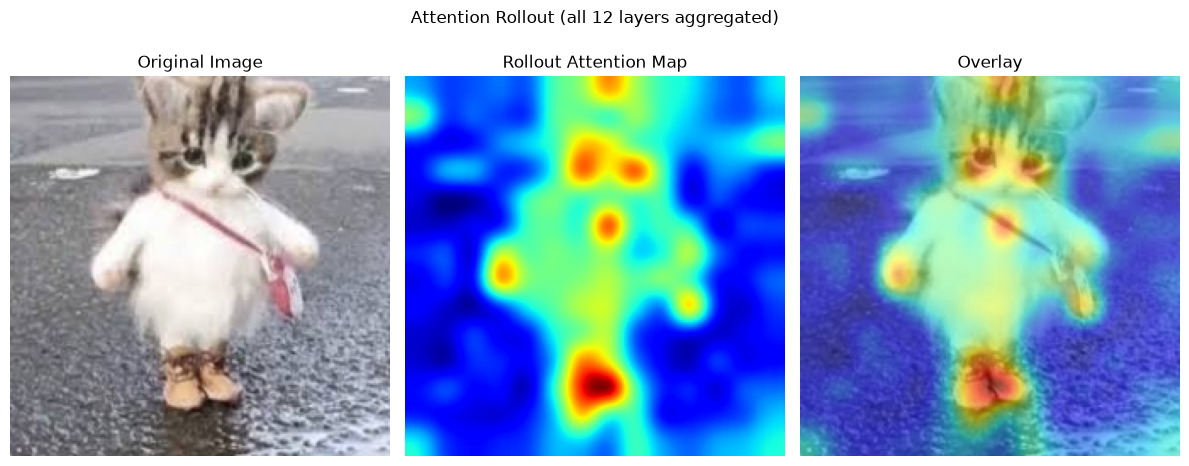

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter

def attention_rollout(attentions):
    # start with identity matrix — at layer 0, each token "attends to itself" perfectly
    rollout = torch.eye(attentions[0].size(-1))

    for attention in attentions:
        # average across all heads for this layer — shape: (seq_len, seq_len)
        attention_heads_fused = attention[0].mean(dim=0)

        # add identity matrix (residual connection in attention)
        attention_heads_fused = attention_heads_fused + torch.eye(attention_heads_fused.size(-1))

        # normalize rows so they sum to 1 again
        attention_heads_fused = attention_heads_fused / attention_heads_fused.sum(dim=-1, keepdim=True)

        # multiply into running rollout — propagates attention across layers
        rollout = torch.matmul(attention_heads_fused, rollout)

    return rollout

# run model with attentions
with torch.no_grad():
    outputs = vit_model(**inputs, output_attentions=True)

attentions = outputs.attentions  # tuple of 12 tensors, one per layer

# compute rollout across all 12 layers
rollout = attention_rollout(attentions)

# extract CLS token's attention to all patch tokens
# rollout shape: (seq_len, seq_len) = (197, 197)
# row 0 = CLS token, columns 1: = patch tokens
num_patches = 14 * 14  # 196 for 224x224 with 16x16 patches
cls_attention = rollout[0, 1:]  # shape: (196,)

# reshape flat attention vector into 14x14 spatial grid
cls_attention = cls_attention.reshape(14, 14).numpy()

# normalize to 0-1
cls_attention = (cls_attention - cls_attention.min()) / (cls_attention.max() - cls_attention.min())

# upsample 14x14 -> 224x224
attn_img = Image.fromarray((cls_attention * 255).astype(np.uint8))
attn_img_resized = attn_img.resize((224, 224), resample=Image.BICUBIC)  # BICUBIC = smoother than BILINEAR

# apply gaussian blur to smooth the blocky patch boundaries
attn_img_resized = attn_img_resized.filter(ImageFilter.GaussianBlur(radius=2))
attn_resized_np = np.array(attn_img_resized) / 255.0

# overlay on original image
original_resized = image.resize((224, 224))

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_resized)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(attn_resized_np, cmap="jet")
plt.title("Rollout Attention Map")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(original_resized)
plt.imshow(attn_resized_np, cmap="jet", alpha=0.5)
plt.title("Overlay")
plt.axis("off")

plt.suptitle("Attention Rollout (all 12 layers aggregated)")
plt.tight_layout()
plt.savefig("vit_attention_rollout.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Patch-Masking Experiment

In [16]:
import copy

def mask_patches(pixel_values, patch_size=16, mask_fraction=0.3, mode="random"):
    """
    pixel_values: tensor of shape (1, 3, 224, 224)
    mode: "random" or "center"
    """
    img = pixel_values.clone()
    num_patches_per_side = 224 // patch_size  # 14
    total_patches = num_patches_per_side ** 2  # 196
    num_to_mask = int(total_patches * mask_fraction)

    if mode == "random":
        patch_indices = np.random.choice(total_patches, num_to_mask, replace=False)
    elif mode == "center":

        center = num_patches_per_side // 2
        coords = [(i, j) for i in range(num_patches_per_side) for j in range(num_patches_per_side)]
        coords.sort(key=lambda c: (c[0]-center)**2 + (c[1]-center)**2)
        center_coords = coords[:num_to_mask]
        patch_indices = [i * num_patches_per_side + j for (i, j) in center_coords]

    for idx in patch_indices:
        row = idx // num_patches_per_side
        col = idx % num_patches_per_side
        img[:, :, row*patch_size:(row+1)*patch_size, col*patch_size:(col+1)*patch_size] = 0

    return img

In [17]:
def predict(pixel_values):
    with torch.no_grad():
        out = vit_model(pixel_values=pixel_values)
    idx = out.logits.argmax(-1).item()
    return vit_model.config.id2label[idx]

inputs = processor(images=image, return_tensors="pt")
original_pixels = inputs["pixel_values"]

print("Original:", predict(original_pixels))

for frac in [0.1, 0.3, 0.5, 0.7]:
    masked_random = mask_patches(original_pixels, mask_fraction=frac, mode="random")
    masked_center = mask_patches(original_pixels, mask_fraction=frac, mode="center")

    print(f"\nMask fraction: {frac}")
    print("  Random masking  ->", predict(masked_random))
    print("  Center masking  ->", predict(masked_center))

Original: tabby, tabby cat

Mask fraction: 0.1
  Random masking  -> tabby, tabby cat
  Center masking  -> tabby, tabby cat

Mask fraction: 0.3
  Random masking  -> Angora, Angora rabbit
  Center masking  -> tabby, tabby cat

Mask fraction: 0.5
  Random masking  -> tabby, tabby cat
  Center masking  -> tabby, tabby cat

Mask fraction: 0.7
  Random masking  -> Angora, Angora rabbit
  Center masking  -> kuvasz


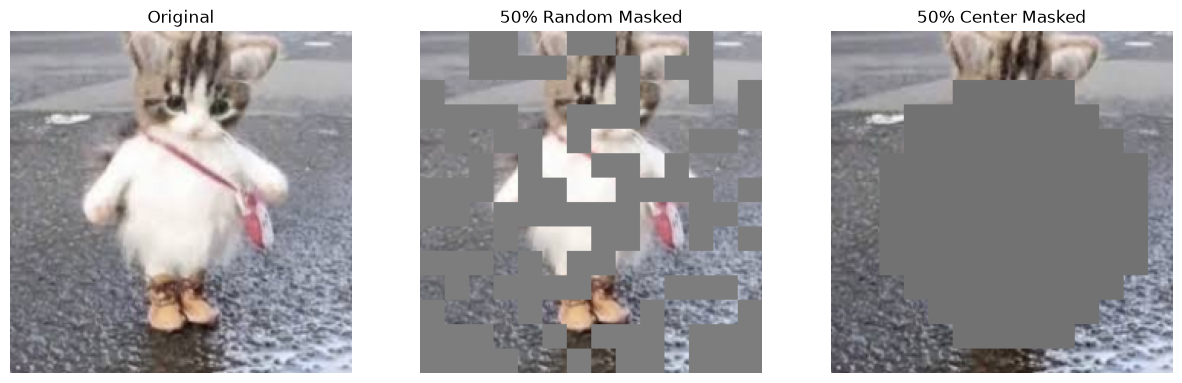

In [18]:
def tensor_to_img(pixel_values):
    img = pixel_values[0].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    return img

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(tensor_to_img(original_pixels)); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(tensor_to_img(mask_patches(original_pixels, mask_fraction=0.5, mode="random"))); axes[1].set_title("50% Random Masked"); axes[1].axis("off")
axes[2].imshow(tensor_to_img(mask_patches(original_pixels, mask_fraction=0.5, mode="center"))); axes[2].set_title("50% Center Masked"); axes[2].axis("off")
plt.savefig("vit_masking_examples.png", dpi=150)
plt.show()

## 5. CLS Token vs. Mean-Pooled Patch Tokens

In [19]:
from transformers import ViTModel

vit_backbone = ViTModel.from_pretrained(model_name)
vit_backbone.eval()

def get_embeddings(pixel_values):
    with torch.no_grad():
        outputs = vit_backbone(pixel_values=pixel_values)
        last_hidden = outputs.last_hidden_state

    cls_embedding = last_hidden[:, 0, :]
    mean_embedding = last_hidden[:, 1:, :].mean(dim=1)
    return cls_embedding, mean_embedding

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 6455.23it/s]
[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms, models

transform_vit = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

probe_train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_vit)
probe_test  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_vit)

rng = np.random.default_rng(6767)

train_indices = rng.choice(len(probe_train), 3000, replace=False)
test_indices = rng.choice(len(probe_test), 1000, replace=False)

train_subset = Subset(probe_train, train_indices)
test_subset = Subset(probe_test, test_indices)

train_loader_probe = DataLoader(train_subset, batch_size=32, shuffle=False)
test_loader_probe  = DataLoader(test_subset, batch_size=32, shuffle=False)

In [22]:
def extract_all(loader):
    cls_feats, mean_feats, labels = [], [], []
    for x, y in loader:
        cls_emb, mean_emb = get_embeddings(x)
        cls_feats.append(cls_emb.numpy())
        mean_feats.append(mean_emb.numpy())
        labels.append(y.numpy())
    return np.concatenate(cls_feats), np.concatenate(mean_feats), np.concatenate(labels)

train_cls, train_mean, train_labels = extract_all(train_loader_probe)
test_cls, test_mean, test_labels = extract_all(test_loader_probe)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

probe_cls = LogisticRegression(max_iter=1000)
probe_cls.fit(train_cls, train_labels)
acc_cls = accuracy_score(test_labels, probe_cls.predict(test_cls))

probe_mean = LogisticRegression(max_iter=1000)
probe_mean.fit(train_mean, train_labels)
acc_mean = accuracy_score(test_labels, probe_mean.predict(test_mean))

print(f"CLS token probe accuracy: {acc_cls:.4f}")
print(f"Mean-pooled probe accuracy: {acc_mean:.4f}")

CLS token probe accuracy: 0.9560
Mean-pooled probe accuracy: 0.9530


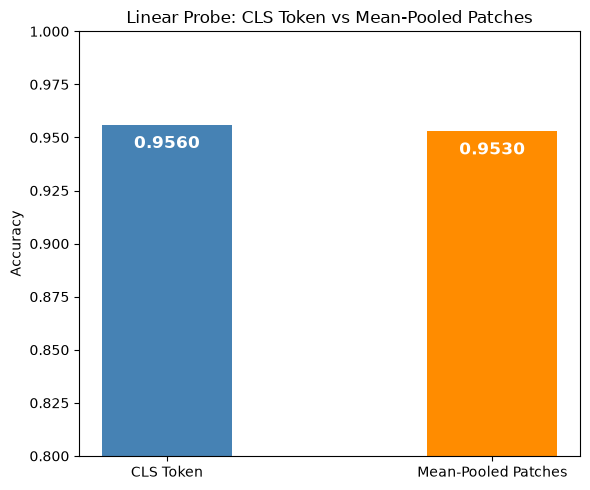

In [26]:
labels = ["CLS Token", "Mean-Pooled Patches"]
accuracies = [acc_cls, acc_mean]
colors = ["steelblue", "darkorange"]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, accuracies, color=colors, width=0.4)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() - 0.005,
             f"{acc:.4f}", 
             ha="center", va="top", 
             fontsize=12, color="white", fontweight="bold")

plt.ylim(0.80, 1)  # tighter range so bars fill the space and labels sit clearly inside
plt.ylabel("Accuracy")
plt.title("Linear Probe: CLS Token vs Mean-Pooled Patches")  
plt.tight_layout()
plt.savefig("cls_vs_meanpool.png", dpi=150, bbox_inches="tight")  # bbox_inches fixes title cutoff
plt.show()